<a href="https://colab.research.google.com/github/AlexitoFernandez/practicas-google-colab/blob/unidad-4/Practica_4_K_Means_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#"Machine Learning y Deep Learning"
##Unidad IV
### **Practica 4 - Segmentación de prestatarios con K-Means**
Alumno: Jorge Alejandro Fernández De Los Santos.

Facilitador: José Gabriel Rodríguez Rivas.


In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

# Cargar datos
file_id = '1HBU_efbbPg378pZvLZ1AtvRFAKrEFsob'
output = 'lending_club_2007_2011_6_states.csv'
gdown.download(id=file_id, output=output, quiet=False)
prestamos_df= pd.read_csv(output)
print(prestamos_df.head())

Downloading...
From: https://drive.google.com/uc?id=1HBU_efbbPg378pZvLZ1AtvRFAKrEFsob
To: /content/lending_club_2007_2011_6_states.csv
100%|██████████| 7.01M/7.01M [00:00<00:00, 21.0MB/s]

   loan_amnt  funded_amnt  funded_amnt_inv       term  int_rate  installment  \
0       2400         2400           2400.0  36 months     15.96        84.33   
1      10000        10000          10000.0  36 months     13.49       339.31   
2       3000         3000           3000.0  36 months     18.64       109.43   
3       5600         5600           5600.0  60 months     21.28       152.39   
4       5375         5375           5350.0  60 months     12.69       121.45   

  grade sub_grade            emp_title emp_length  ... application_type  \
0     C        C5                  NaN  10+ years  ...       Individual   
1     C        C1  AIR RESOURCES BOARD  10+ years  ...       Individual   
2     E        E1      MKC Accounting     9 years  ...       Individual   
3     F        F2                  NaN    4 years  ...       Individual   
4     B        B5            Starbucks   < 1 year  ...       Individual   

   acc_now_delinq chargeoff_within_12_mths delinq_amnt pub_rec_bankr

In [8]:
#Selección de variables financieras relevantes
features = [
'funded_amnt',
'int_rate',
'annual_inc',
'dti',
'revol_util',
'grade',
'purpose'
]
data = prestamos_df[features].dropna()
data.head()

,funded_amnt,int_rate,annual_inc,dti,revol_util,grade,purpose
0,2400,15.96,12252.0,8.72,98.5,C,small_business
1,10000,13.49,49200.0,20.00,21.0,C,other
2,3000,18.64,48000.0,5.35,87.5,E,car
3,5600,21.28,40000.0,5.55,32.6,F,small_business
4,5375,12.69,15000.0,18.08,36.5,B,other


In [10]:
data_encoded = pd.get_dummies(data, columns=['grade', 'purpose'], drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_encoded)

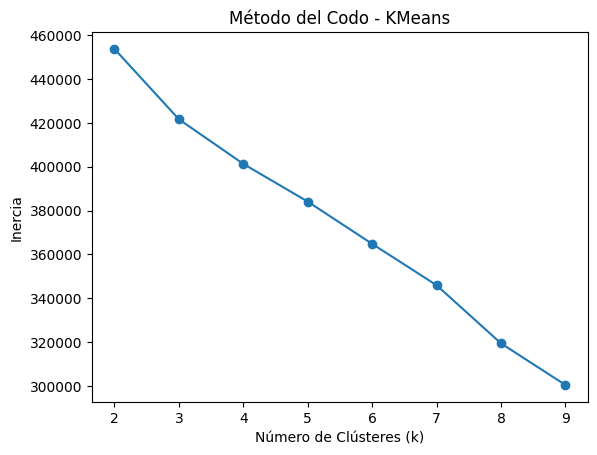

In [12]:
#Determinamos el número óptimo de clústeres (método del codo)
inertia = []
K = range(2, 10)
for k in K:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)
plt.plot(K, inertia, marker='o')
plt.title("Método del Codo - KMeans")
plt.xlabel("Número de Clústeres (k)")
plt.ylabel("Inercia")
plt.show()

In [17]:
#K-Means con 3 Clusters
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data["cluster"] = clusters
data_encoded["cluster"] = clusters # Add cluster labels to the encoded data for descriptive analysis

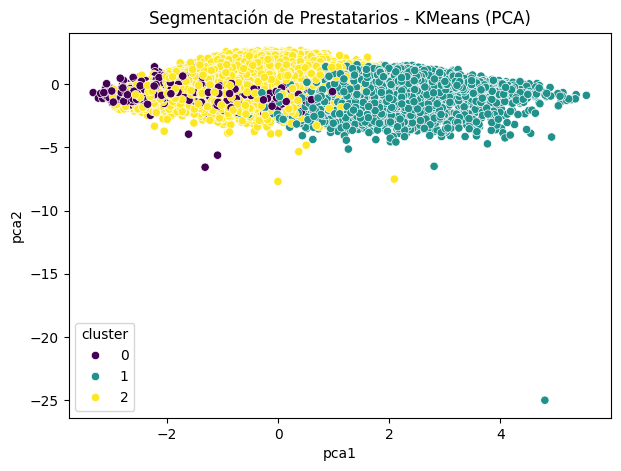

In [14]:
#Visualización PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
data["pca1"], data["pca2"] = pca_result[:, 0], pca_result[:, 1]
plt.figure(figsize=(7,5))
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis")
plt.title("Segmentación de Prestatarios - KMeans (PCA)")
plt.show()


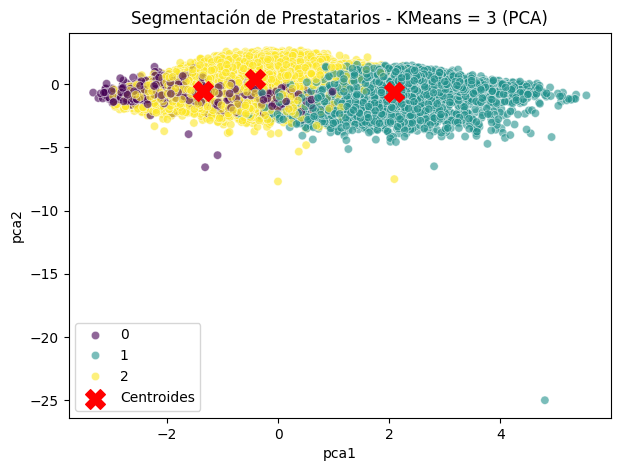

In [15]:
#Agregar el centroide
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.figure(figsize=(7,5))
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis", alpha=0.6)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c="red", marker="X", label="Centroides")
plt.title("Segmentación de Prestatarios - KMeans = 3 (PCA)")
plt.legend()
plt.show()

In [18]:
#Análisis descriptivo de cada clúster
# Calculate descriptive statistics using the data_encoded DataFrame
# which contains only numerical features (including one-hot encoded ones).
resumen_clusters = data_encoded.groupby("cluster").mean().round(2)
print("\nPromedios por clúster:\n", resumen_clusters)


Promedios por clúster:
          funded_amnt  int_rate  annual_inc    dti  revol_util  grade_B  \
cluster                                                                  
0            7177.19     10.77    62577.94  11.27       39.31     0.35   
1           14524.62     17.02    79027.99  13.89       66.93     0.00   
2           10818.36     10.59    70377.03  13.15       45.55     0.41   

         grade_C  grade_D  grade_E  grade_F  ...  purpose_home_improvement  \
cluster                                      ...                             
0           0.22     0.08     0.01     0.00  ...                      0.00   
1           0.00     0.54     0.30     0.12  ...                      0.06   
2           0.28     0.00     0.00     0.00  ...                      0.09   

         purpose_house  purpose_major_purchase  purpose_medical  \
cluster                                                           
0                 0.00                    0.30             0.00   
1           

**Conclusiones**
**Clúster 2 (Bajo Riesgo):** Clientes con el mejor balance financiero general. Disponen de ingresos sólidos, acceden a montos de préstamo respetables con la tasa de interés más baja del análisis (10.59%) y mantienen una utilización de crédito saludable, respaldados por las mejores calificaciones crediticias.

**Clúster 1 (Riesgo Alto por comportamiento crediticio):** Usuarios que solicitan los montos más elevados (~ 14.5 k) pero que arrastran un perfil de riesgo severo. Presentan la mayor utilización de líneas de crédito (casi 67%), las peores calificaciones crediticias de la muestra (D, E y F) y, en consecuencia, las tasas de interés más punitivas. Representan el foco de mayor riesgo de impago.

**Clúster 0 (Riesgo Moderado por capacidad financiera):** Usuarios con los ingresos más ajustados de la segmentación (~ 62.5 k). Aunque muestran un comportamiento prudente con deudas pequeñas y tasas aceptables, su margen financiero es estrecho, por lo que podrían ser vulnerables ante variaciones en su economía, a pesar de estar clasificados en grados crediticios estables (B y C).

#Evaluacion del Clustering
A diferencia del aprendizaje supervisado, el clustering no tiene etiquetas verdaderas, por lo que su evaluación se realiza mediante medidas de coherencia interna y separación entre grupos, tales como:
* Inercia o Within-Cluster Sum of Squares (WCSS).
* Coeficiente de Silhouette (Silhouette Score).
* Davies–Bouldin Index.

Estas métricas ayudan a determinar qué tan compactos y separados están los grupos formados.
Interpretación del Silhouette Score
El Silhouette Score oscila entre:
* 1.0 → Clústeres muy bien separados y compactos
* 0.5 → Separación clara y estructura definida
* 0.2 - 0.3 → Estructura débil pero existente
* 0.0 → Los clústeres se mezclan, pobre separación
* < 0 → Clustering incorrecto

**Interpretación de la Inercia**
* Inercia = ∑ distancia al centroide 2
* La inercia por sí sola no se interpreta directamente, sino que:
  * Se usa para comparar diferentes valores de k.
  * Una inercia menor significa grupos más compactos.

In [19]:

from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette score con k = 3:", sil_score)
print("Inercia con k = 3:", kmeans.inertia_)

Silhouette score con k = 3: 0.15376495855317698
Inercia con k = 3: 421645.15996847546


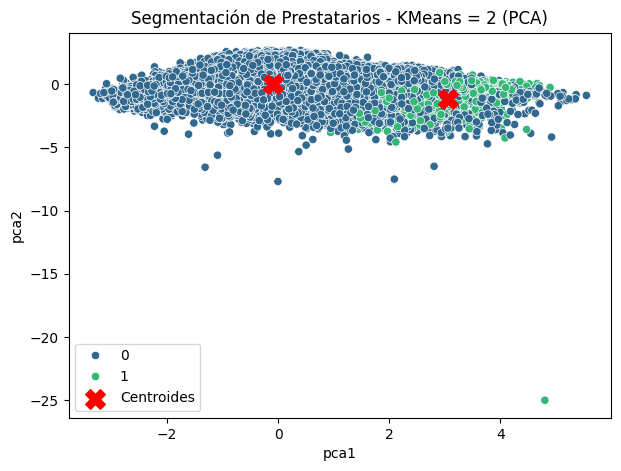

In [20]:
#Experimentar con Clusters = 2
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data["cluster"] = clusters
#Visualización PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
data["pca1"], data["pca2"] = pca_result[:, 0], pca_result[:, 1]
plt.figure(figsize=(7,5))
centroids_pca = pca.transform(kmeans.cluster_centers_)
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis")
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c="red", marker="X", label="Centroides")
plt.title("Segmentación de Prestatarios - KMeans = 2 (PCA)")
plt.legend()
plt.show()

**Clúster 0 — Prestatarios de Alto Riesgo Crediticio**

Promedios:
* funded_amnt: 13,536 (monto medio–alto)
* int_rate: 15.36% (claramente más alto)
* annual_inc: 76,392
* dti: 14.55 (elevado)
* revol_util: 67.49% (muy alto uso del crédito)
* grade_code: 2.83 (mala calificación)
* purpose_code: 3.49

Este clúster agrupa a los clientes:
* Con tasas altas
* Peor calificación crediticia
* Alta utilización del crédito
* Mayor endeudamiento relativo (dti alto)
* Monto del préstamo ligeramente más alto

Conclusión del grupo: Son vistos por LendingClub como riesgo alto, razón por la cual se les asignan tasas de interés mucho mayores para compensar la probabilidad de impago.

**Clúster 1 — Prestatarios de Bajo Riesgo Crediticio**

Promedios:

* funded_amnt: 9,231 (monto bajo-moderado)
* int_rate: 9.66% (mucho más baja)
* annual_inc: 67,125
* dti: 11.86 (aceptable)
* revol_util: 36.00% (moderado-bajo)
* grade_code: 0.69 (excelente calificación crediticia)
* purpose_code: 4.22

Este clúster agrupa a los clientes con:
* Mejores calificaciones crediticias
* Tasas más bajas
* Mejor manejo de deuda
* Baja utilización del crédito
* Menos riesgo para el prestamista

In [21]:
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette score con k = 2:", sil_score)
print("Inercia con k = 2", kmeans.inertia_)

Silhouette score con k = 2: 0.3277532177772175
Inercia con k = 2 453697.76881956856


In [23]:
#Experimentar con Clusters = 4
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data["cluster"] = clusters

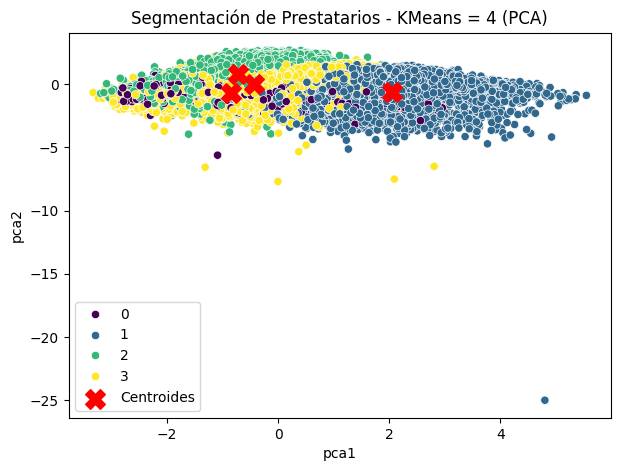

In [24]:
# Visualización PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
data["pca1"], data["pca2"] = pca_result[:, 0], pca_result[:, 1]
plt.figure(figsize=(7,5))
centroids_pca = pca.transform(kmeans.cluster_centers_)
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis")
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c="red", marker="X", label="Centroides")
plt.title("Segmentación de Prestatarios - KMeans = 4 (PCA)")
plt.legend()
plt.show()

In [26]:
#Análisis descriptivo de cada clúster
summary = data_encoded.groupby("cluster").mean().round(2)
print("\nPromedios por clúster:\n", summary)


Promedios por clúster:
          funded_amnt  int_rate  annual_inc    dti  revol_util  grade_B  \
cluster                                                                  
0            7177.19     10.77    62577.94  11.27       39.31     0.35   
1           14524.62     17.02    79027.99  13.89       66.93     0.00   
2           10818.36     10.59    70377.03  13.15       45.55     0.41   

         grade_C  grade_D  grade_E  grade_F  ...  purpose_home_improvement  \
cluster                                      ...                             
0           0.22     0.08     0.01     0.00  ...                      0.00   
1           0.00     0.54     0.30     0.12  ...                      0.06   
2           0.28     0.00     0.00     0.00  ...                      0.09   

         purpose_house  purpose_major_purchase  purpose_medical  \
cluster                                                           
0                 0.00                    0.30             0.00   
1           

In [28]:
#Optimizacion
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd
resultados = []
K = range(2, 13)   # Ajustar el rango dependiendo del rango K a probar
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)
    calinski = calinski_harabasz_score(X_scaled, labels)
    davies = davies_bouldin_score(X_scaled, labels)
    resultados.append({
        "k": k,
        "inercia": inertia,
        "silhouette": silhouette,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies
    })
df_resultados = pd.DataFrame(resultados)
df_resultados

,k,inercia,silhouette,calinski_harabasz,davies_bouldin
0,2,453697.768820,0.327753,1036.138010,1.143508
1,3,421645.159968,0.153765,1313.271621,2.775391
2,4,401294.418099,0.122949,1256.007882,2.584630
3,5,384107.109204,0.145657,1206.542528,2.440958
4,6,364843.329355,0.174733,1226.110821,2.225421
5,7,345994.547521,0.193478,1257.886276,2.093459
6,8,319484.469216,0.202938,1403.263510,1.723920
7,9,300524.852227,0.214304,1462.027845,1.576102
8,10,287503.068621,0.229710,1458.414904,1.560653
9,11,266985.406001,0.243770,1566.133958,1.438224


In [29]:
# Normalizamos algunas métricas para comparar
df_norm = df_resultados.copy()
# Queremos silhouette ALTO, calinski ALTO, davies BAJO, inertia BAJA
df_norm["rank"] = (
df_norm["silhouette"].rank(ascending=False) +
df_norm["calinski_harabasz"].rank(ascending=False) +
df_norm["davies_bouldin"].rank(ascending=True) +
df_norm["inercia"].rank(ascending=True)
)
k_optimo = df_norm.sort_values("rank").iloc[0]["k"]
print("K óptimo según combinación de métricas:", k_optimo)

K óptimo según combinación de métricas: 12.0


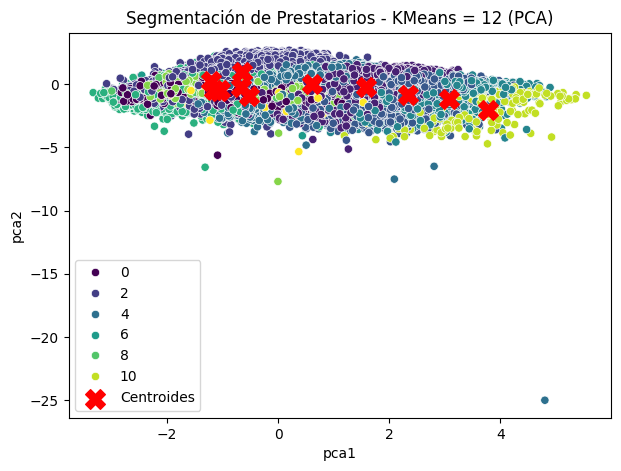

In [30]:
#K-Means = 12 Clusters
kmeans = KMeans(n_clusters=12, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data["cluster"] = clusters
#Visualización PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
data["pca1"], data["pca2"] = pca_result[:, 0], pca_result[:, 1]
plt.figure(figsize=(7,5))
centroids_pca = pca.transform(kmeans.cluster_centers_)
sns.scatterplot(data=data, x="pca1", y="pca2", hue="cluster", palette="viridis")
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c="red", marker="X", label="Centroides")
plt.title("Segmentación de Prestatarios - KMeans = 12 (PCA)")
plt.legend()
plt.show()

In [32]:
# Análisis descriptivo de cada clúster
summary = data_encoded.groupby("cluster").mean().round(2)
print("\nPromedios por clúster:\n", summary)


Promedios por clúster:
          funded_amnt  int_rate  annual_inc    dti  revol_util  grade_B  \
cluster                                                                  
0            7177.19     10.77    62577.94  11.27       39.31     0.35   
1           14524.62     17.02    79027.99  13.89       66.93     0.00   
2           10818.36     10.59    70377.03  13.15       45.55     0.41   

         grade_C  grade_D  grade_E  grade_F  ...  purpose_home_improvement  \
cluster                                      ...                             
0           0.22     0.08     0.01     0.00  ...                      0.00   
1           0.00     0.54     0.30     0.12  ...                      0.06   
2           0.28     0.00     0.00     0.00  ...                      0.09   

         purpose_house  purpose_major_purchase  purpose_medical  \
cluster                                                           
0                 0.00                    0.30             0.00   
1           

**Segmentos de Riesgo Crítico y Muy Alto
Cluster 3 — Alto Monto, Alta Tasa y Utilización Máxima**

**Características Principales:** funded_amnt muy alto (20,858) | int_rate altísima (18.12%) | revol_util altísima (69.99%) | grade_code deficiente (4.06) | dti alto (15.31) | annual_inc alto (93,363).

* Interpretación: Clientes de riesgo crediticio crítico. A pesar de tener buenos ingresos, solicitan montos masivos, operan al límite de sus tarjetas y arrastran el peor score. La entidad financiera les asigna tasas punitivas debido a su altísima probabilidad de impago.

**Cluster 6 — Baja Capacidad y Uso Excesivo del Crédito**

* Características Principales: annual_inc modesto (63,919) | int_rate alta (14.32%) | revol_util muy alta (63.54%) | grade_code malo (2.39) | dti alto (13.20) | purpose_code ≈ 9.56 (destinado a rubros volátiles como vacation, small business o medical).

**Interpretación: Clientes en una situación financiera comprometida**

Combinan ingresos limitados con un uso intensivo de líneas de crédito para propósitos de consumo o emergencias, lo que deteriora su perfil y aumenta su peligrosidad crediticia.

**Cluster 4 — Ingresos Bajos, Interés Alto y Mal Score**
Características Principales: annual_inc bajo (60,026) | int_rate alta (14.43%) | revol_util altísima (70.97%) | grade_code malo (2.43).

**Interpretación:**
 Perfil financieramente vulnerable. Comparte las señales de alarma del clúster 3 (pésima utilización y mal score), pero se diferencia en que solicita montos más pequeños debido a que sus bajos ingresos restringen su capacidad de endeudamiento absoluto.

**Segmentos de Riesgo Moderado y Casos Especiales
Cluster 2 — Ingresos Bajos con Carga de Deuda Alta
Características Principales:** dti críticamente alto (19.67) | revol_util medio (50.25%) | annual_inc bajo (56,182) | int_rate baja-media (9.99%) | grade_code relativamente bueno (0.76).

Interpretación: Representa un riesgo oculto por sobreendeudamiento. Aunque mantienen un score crediticio e intereses saludables en el papel, la proporción de su ingreso destinada a pagar deudas (dti) es alarmante, volviéndolos inestables ante cualquier imprevisto económico.

**Cluster 0 — Caso Atípico con Ingreso Extremadamente Alto**
Características Principales: annual_inc extremo (2,223,112) | dti mínimo (1.71) | funded_amnt moderado (7,910) | grade_code excelente (0.86) | int_rate moderada (9.73%).

**Interpretación:** Este grupo actúa como un capturador de outliers (valores atípicos). Está integrado por un número reducido de personas con solvencia extraordinaria (ejecutivos, directores o empresarios). Es una buena práctica analítica mantenerlos en un clúster aislado para no sesgar las métricas de los grupos principales.

**Segmentos de Bajo Riesgo y Clientes Premium
Cluster 5 — Alto Monto, Buen Ingreso y Riesgo Bajo-Medio**
Características Principales: funded_amnt alto (21,931) | annual_inc alto (116,167) | dti saludable (11.12) | revol_util moderado (38.34%) | grade_code aceptable (1.40).

Interpretación: Clientes altamente valiosos y solventes. Tienen la capacidad económica para respaldar y absorber deudas grandes, manteniendo bajo control la utilización de sus líneas de crédito.

**Cluster 1 — Perfil Premium Estable (Muy Bajo Riesgo)**
Características Principales: int_rate baja (8.72%) | revol_util baja (27.98%) | dti bajo (7.91) | grade_code excelente (0.44) | annual_inc medio-alto (66,947) | purpose_code ≈ 2 (enfocado en inversión: education, car, home improvement).

*Interpretación:* El segmento más saludable e ideal de la cartera. Presentan un historial intachable, baja dependencia del crédito revolvente y solicitan préstamos con fines constructivos, asegurando las tasas de interés más competitivas del mercado.

Cluster 7 — Buen Score, Baja Utilización y Finanzas Sanas
Características Principales: int_rate baja (9.20%) | revol_util muy baja (22.33%) | grade_code muy bueno (0.56) | annual_inc moderado (61,928) | dti moderado-bajo (9.00).

**Interpretación:** Clientes con una excelente cultura financiera. A pesar de contar con ingresos medianos, demuestran una gestión impecable del dinero, nulo sobreendeudamiento y un riesgo de impago mínimo para la plataforma.